This is notbook used to train a recommndation similar games used in media logger app

# Setup

In [1]:
# import all required lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

import pickle


In [2]:
# lets read the data from out json file in to a data frame
games_df = pd.read_json("games.json")

In [3]:
games_df.head()

,_id,title,description,averageRating,genre,releaseDate,posterUrl,backdropUrl,isActive,status,platforms,avgPlaytime,developer,youtubeVideoId,__v,createdAt,updatedAt,ageRating
0,68de825e063c7dbcff07c0d8,Hollow Knight: Silksong,Hollow Knight: Silksong is the epic sequel to ...,8.36,"[Action, Adventure, Indie, Platformer]",2025-09-04T00:00:00.000Z,https://images.igdb.com/igdb/image/upload/t_co...,https://media.rawg.io/media/screenshots/79a/79...,True,released,"[Xbox Series S/X, Xbox One, PlayStation 5, Pla...",780.0,Team Cherry,6XGeJwsUP9c,0,2025-10-02T13:47:10.164Z,2025-10-04T16:36:57.444Z,NaN
1,68de82d0063c7dbcff07c0e1,Terraria,Terraria is a 2D action adventure sandbox game...,8.14,"[Action, Indie, Platformer]",2011-05-16T00:00:00.000Z,https://images.igdb.com/igdb/image/upload/t_co...,https://media.rawg.io/media/screenshots/640/64...,True,released,"[Xbox 360, Nintendo 3DS, Xbox One, PlayStation...",900.0,Engine Software,,0,2025-10-02T13:49:04.930Z,2025-10-02T13:49:04.930Z,13.0
2,68de82d0063c7dbcff07c0e6,Horizon Zero Dawn,Horizon Zero Dawn is an experiment. A very imp...,8.56,"[Action, RPG]",2017-02-28T00:00:00.000Z,https://images.igdb.com/igdb/image/upload/t_co...,https://media.rawg.io/media/screenshots/622/62...,True,released,"[PC, PlayStation 4]",660.0,Guerrilla Games,,0,2025-10-02T13:49:04.930Z,2025-10-02T13:49:04.930Z,13.0
3,68de82d0063c7dbcff07c0e7,Metro 2033,Not all post-apocalyptic stories begin in the ...,7.88,"[Action, Shooter]",2010-03-16T00:00:00.000Z,https://images.igdb.com/igdb/image/upload/t_co...,https://media.rawg.io/media/screenshots/b5a/b5...,True,released,"[Xbox 360, PC]",120.0,4A Games,,0,2025-10-02T13:49:04.930Z,2025-10-02T13:49:04.930Z,17.0
4,68de82d0063c7dbcff07c0e2,Dota 2,What used to be an unofficial modded map for t...,6.14,[Action],2013-07-09T00:00:00.000Z,https://images.igdb.com/igdb/image/upload/t_co...,https://media.rawg.io/media/screenshots/7ef/7e...,True,released,"[Linux, PC]",840.0,Valve Software,,0,2025-10-02T13:49:04.930Z,2025-10-02T13:49:04.930Z,NaN


# Data processing

In [4]:
games_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   _id             261 non-null    object 
 1   title           261 non-null    object 
 2   description     261 non-null    object 
 3   averageRating   261 non-null    float64
 4   genre           261 non-null    object 
 5   releaseDate     261 non-null    object 
 6   posterUrl       261 non-null    object 
 7   backdropUrl     261 non-null    object 
 8   isActive        261 non-null    bool   
 9   status          261 non-null    object 
 10  platforms       261 non-null    object 
 11  avgPlaytime     246 non-null    float64
 12  developer       261 non-null    object 
 13  youtubeVideoId  261 non-null    object 
 14  __v             261 non-null    int64  
 15  createdAt       261 non-null    object 
 16  updatedAt       261 non-null    object 
 17  ageRating       206 non-null    flo

lets convert the date to datetime

In [5]:
games_df["releaseDate"] = pd.to_datetime(games_df["releaseDate"] , errors="coerce")
games_df["updatedAt"] = pd.to_datetime(games_df["updatedAt"] , errors="coerce")
games_df["createdAt"] = pd.to_datetime(games_df["createdAt"] , errors="coerce")

In [6]:
games_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   _id             261 non-null    object             
 1   title           261 non-null    object             
 2   description     261 non-null    object             
 3   averageRating   261 non-null    float64            
 4   genre           261 non-null    object             
 5   releaseDate     261 non-null    datetime64[ns, UTC]
 6   posterUrl       261 non-null    object             
 7   backdropUrl     261 non-null    object             
 8   isActive        261 non-null    bool               
 9   status          261 non-null    object             
 10  platforms       261 non-null    object             
 11  avgPlaytime     246 non-null    float64            
 12  developer       261 non-null    object             
 13  youtubeVideoId  261 non-null    obj

# Visualization

## Distribution

lets focus on plotting distribution of all numeric values .

In [7]:
num_columns = games_df.select_dtypes(include='number')
num_columns.columns

Index(['averageRating', 'avgPlaytime', '__v', 'ageRating'], dtype='object')

### Age rating

Text(0.5, 1.0, 'Age rating vs count')

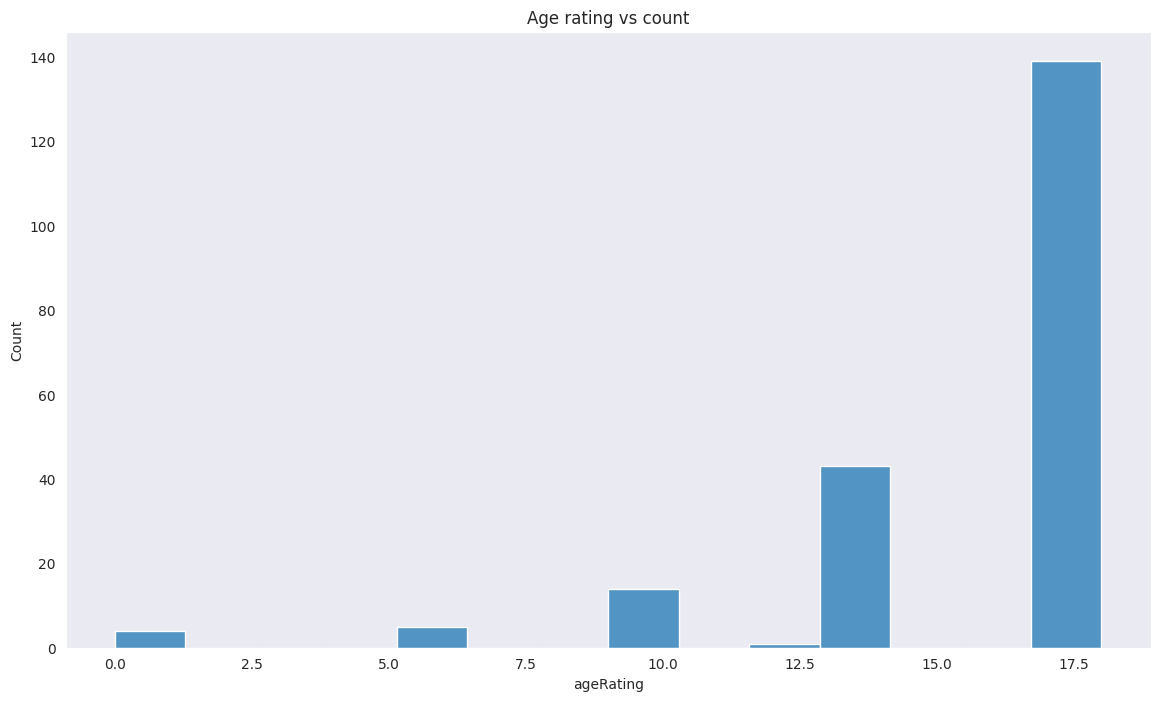

In [8]:
# let plot a hist again the count .
sns.set_style("dark");
plt.figure(figsize=(14, 8));

sns.histplot(x = "ageRating" , data = games_df)
plt.title('Age rating vs count')

Text(0.5, 1.0, 'Age rating vs count')

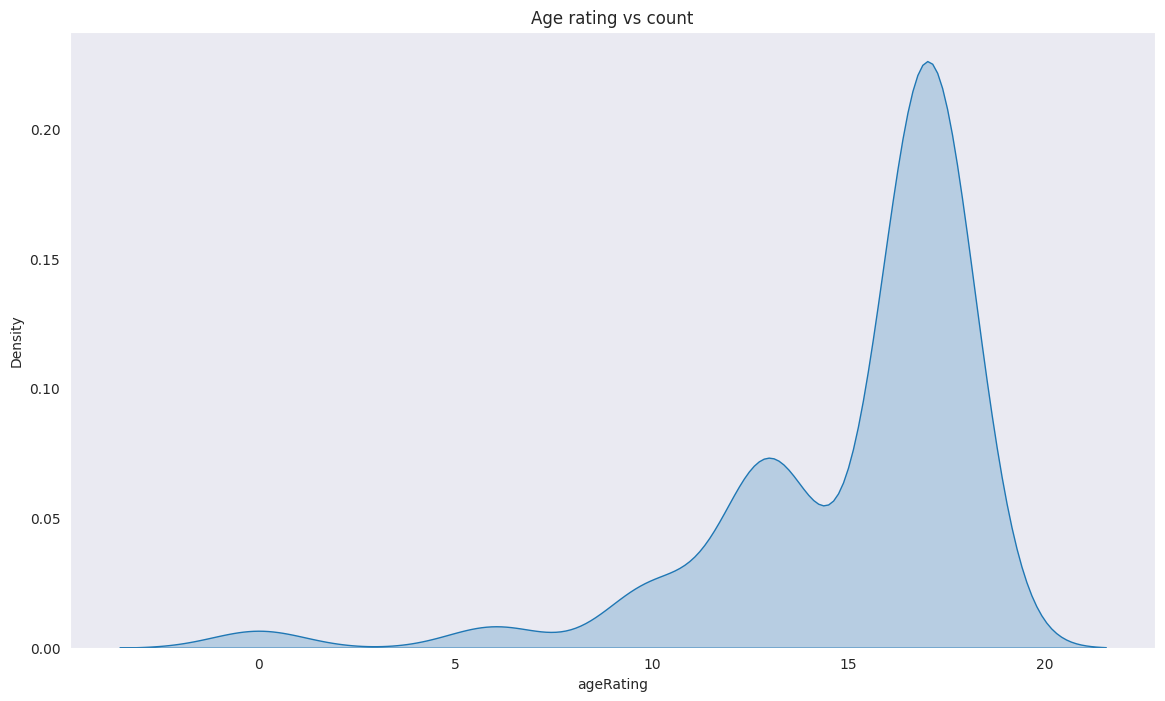

In [9]:
#kde plot
plt.figure(figsize=(14, 8));

sns.kdeplot(x = "ageRating" , data=games_df , fill=True)
plt.title('Age rating vs count')

<Axes: title={'center': 'Age rating vs count'}, xlabel='ageRating', ylabel='count'>

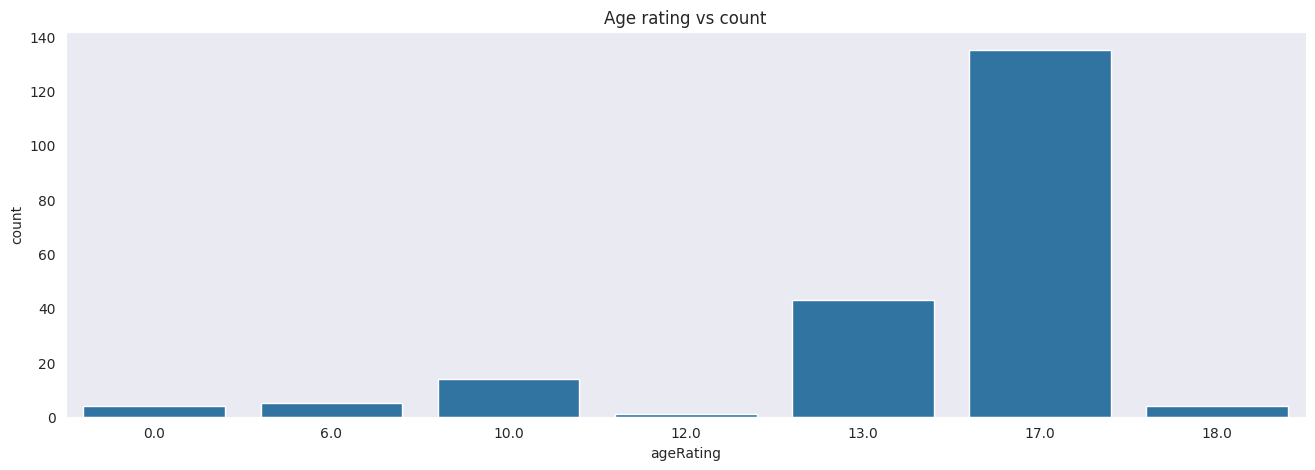

In [10]:
# count plot
plt.figure(figsize=(16 , 5));
plt.title("Age rating vs count")
sns.countplot( x = "ageRating" , data = games_df)

<Axes: title={'center': 'age rating box plot'}, xlabel='ageRating'>

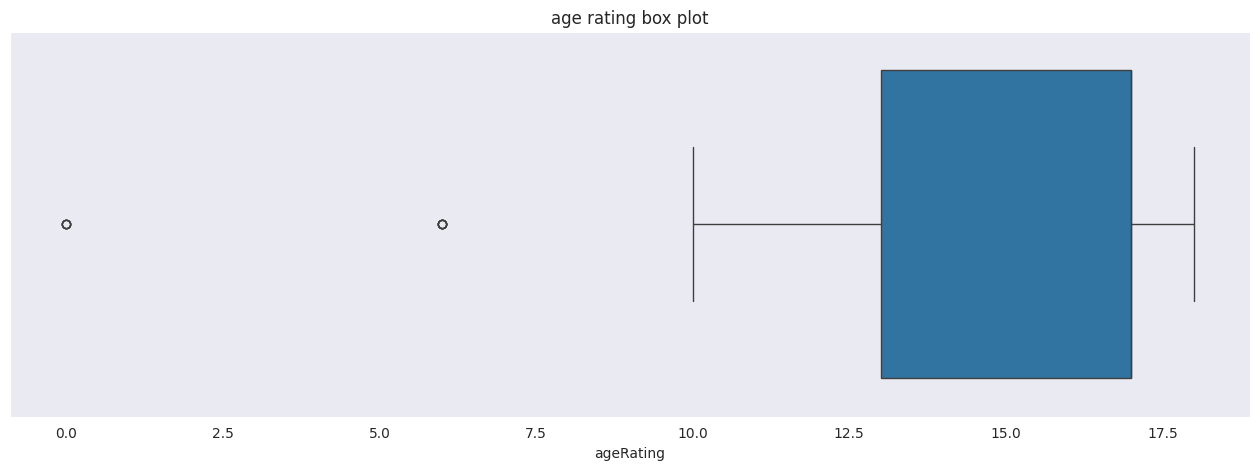

In [11]:
# lets also draw a box plot
plt.figure(figsize=(16 , 5));
plt.title("age rating box plot")
sns.boxplot(x=games_df["ageRating"])

max range at 12- 17

### Average rating

Text(0.5, 1.0, 'Average rating vs count')

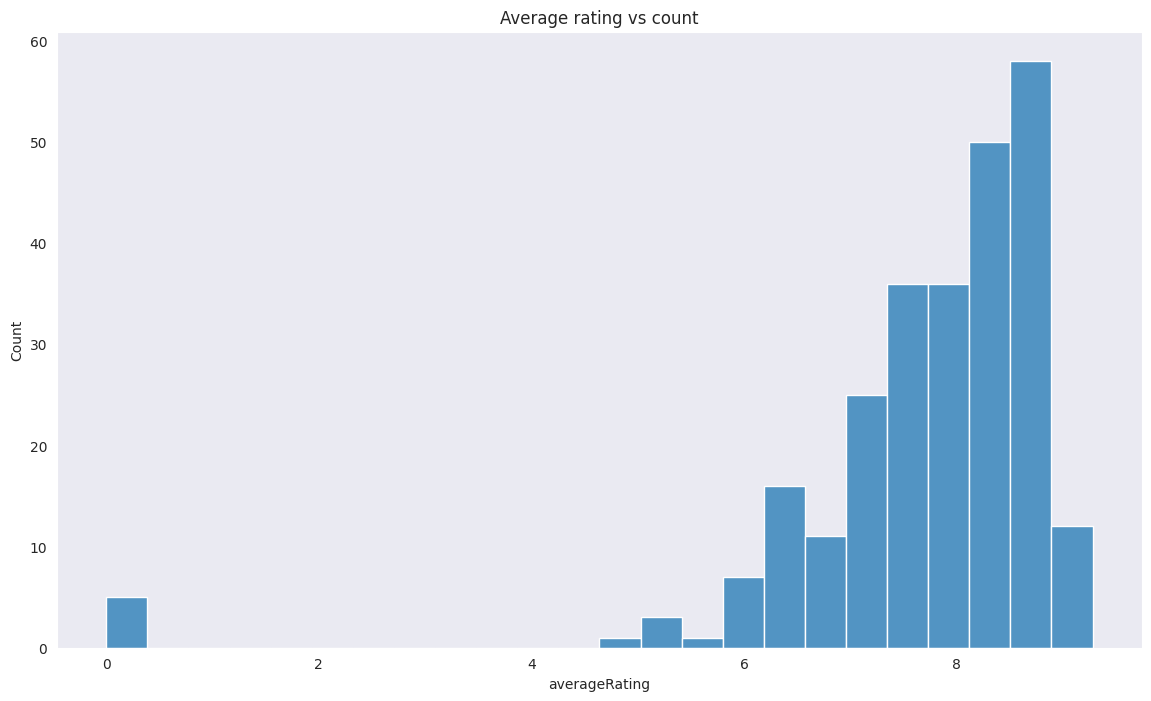

In [12]:
# lets focus on count vs the plot of average rating
plt.figure(figsize=(14, 8));

sns.histplot(x ="averageRating", data = games_df);
plt.title("Average rating vs count")

0 ia same as no rating and will be filtered out on training

<Axes: title={'center': 'average rating box plot'}, xlabel='averageRating'>

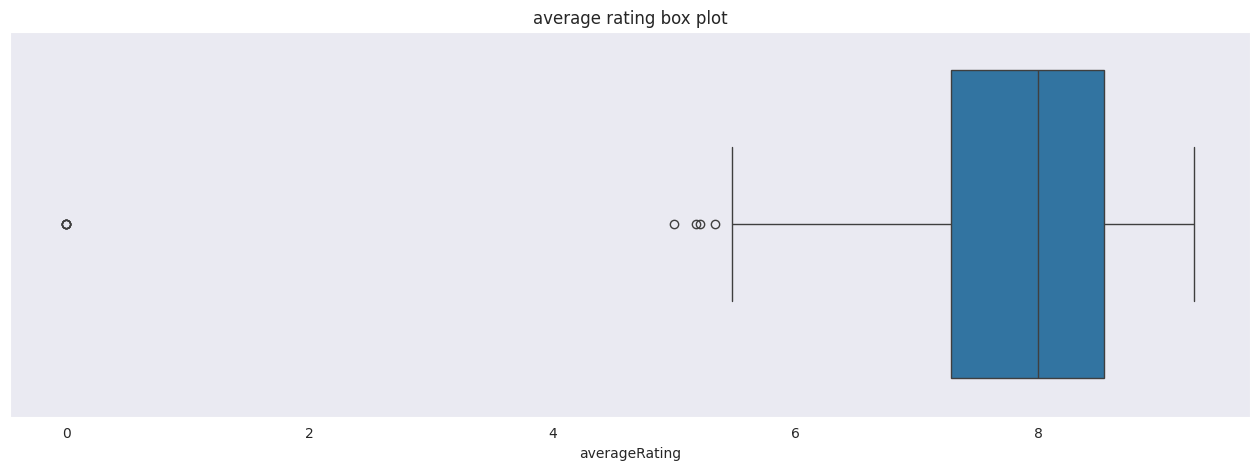

In [14]:
# let drawe the box plot these should not be outliers since we have a limt of 0-10
plt.figure(figsize=(16 , 5));
plt.title("average rating box plot")
sns.boxplot(x=games_df["averageRating"])

### created at

we will only simple draw a kde plot for visulaization , and we will not use this for training

Text(0.5, 1.0, 'created at vs count')

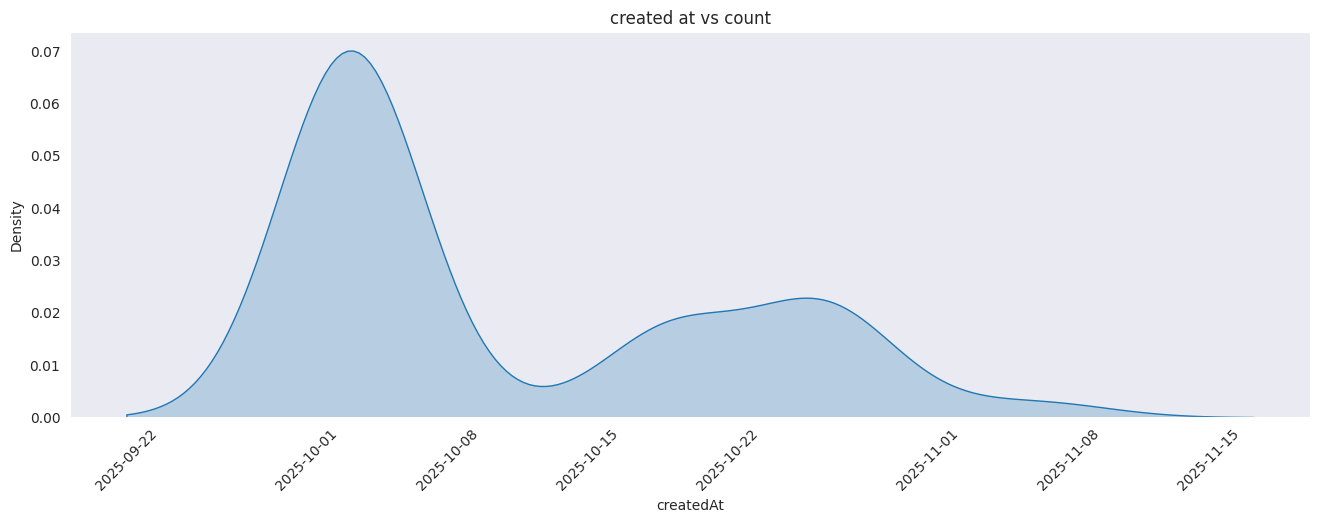

In [15]:
# create a kde plot
plt.figure(figsize=(16 , 5));
sns.kdeplot(x = "createdAt" , data = games_df , fill = True)
plt.xticks(rotation=45)
plt.title("created at vs count")

## Release date

<Axes: title={'center': 'release date  vs count'}, xlabel='releaseDate', ylabel='Count'>

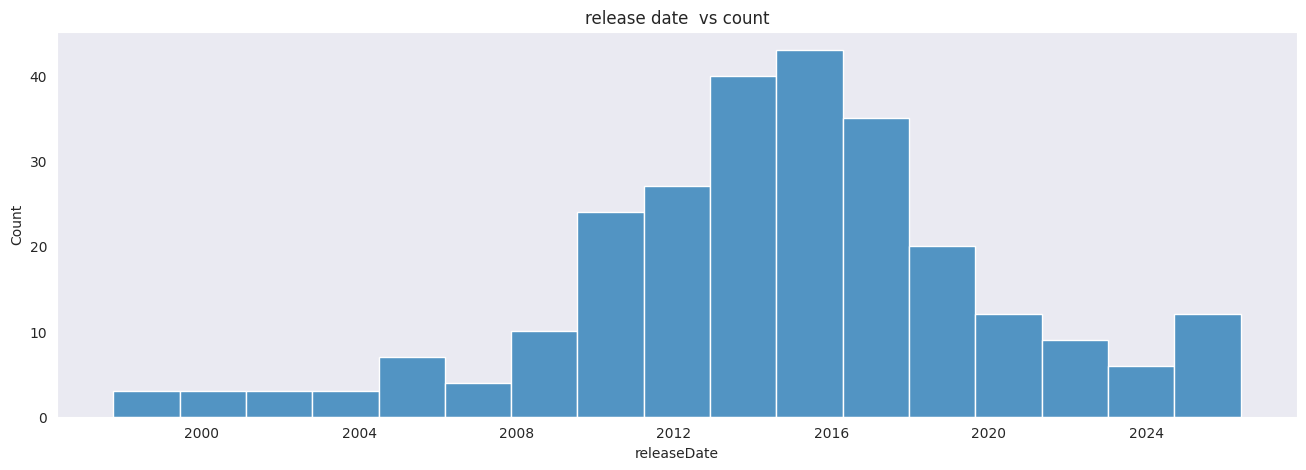

In [17]:
# hist graph for release date vs count
sns.set_style("dark");
plt.figure(figsize=(16 , 5));

plt.title("release date  vs count")
sns.histplot( x = "releaseDate" , data = games_df)

Text(0.5, 1.0, 'release date  vs count')

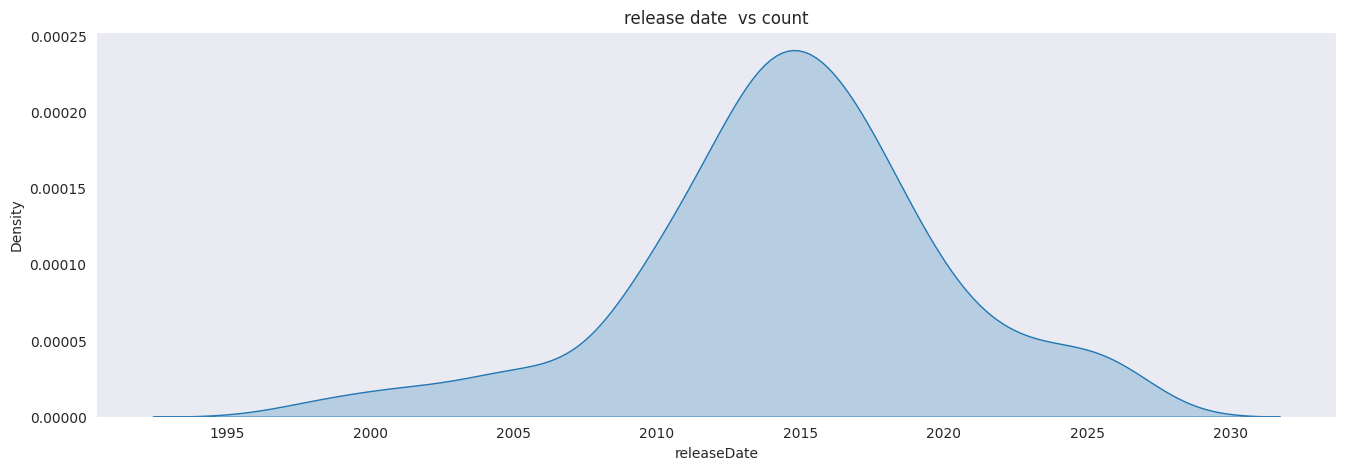

In [18]:
#kde plot
plt.figure(figsize=(16 , 5));
sns.kdeplot(x = "releaseDate" , data = games_df , fill = True)
plt.title("release date  vs count")

<Axes: title={'center': 'release box plot'}, xlabel='releaseDate'>

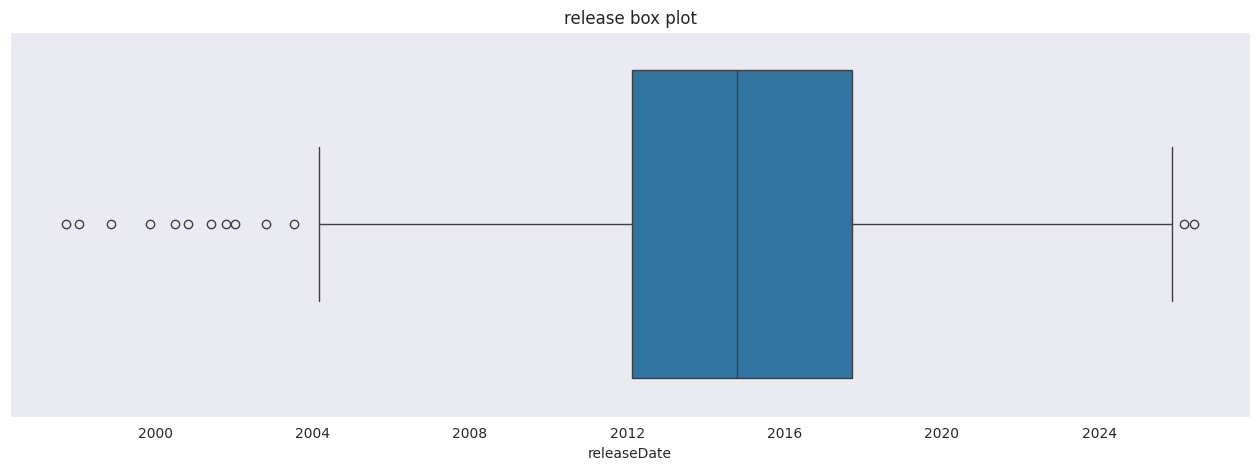

In [19]:
# lets also draw a box plot
plt.figure(figsize=(16 , 5));
plt.title("release box plot")
sns.boxplot(x=games_df["releaseDate"])

we will be imputing any outliers in the date range as per iqr

### Average play time

this can have a wide range .
we are currently storing data in minutes

<Axes: title={'center': 'Average run time vs count '}, xlabel='avgPlaytime', ylabel='Count'>

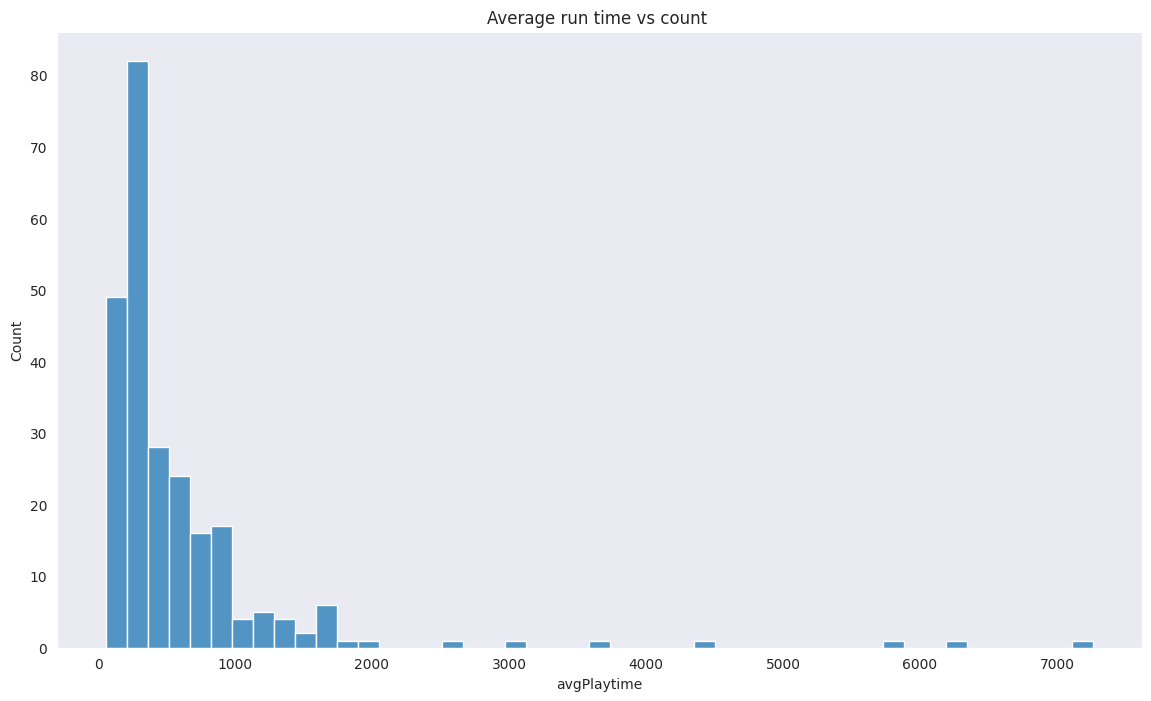

In [21]:
# lets plot hist plot for playtime
plt.figure(figsize=(14, 8));
plt.title("Average run time vs count ")
sns.histplot(x ="avgPlaytime" , data = games_df)

as we can observe there are some at very high play time . they hve to be handled in data cleaning a preocess

<Axes: title={'center': 'play time box plot'}, xlabel='avgPlaytime'>

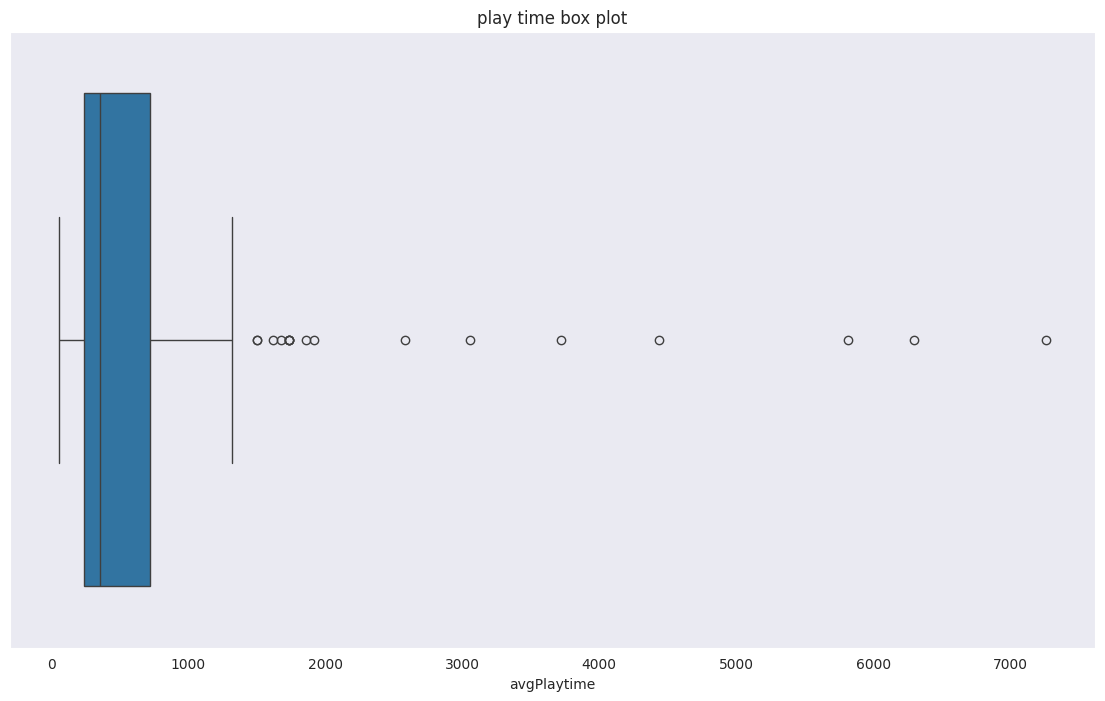

In [22]:
# lets also draw a box plot
plt.figure(figsize=(14 , 8));
plt.title("play time box plot")
sns.boxplot(x= games_df["avgPlaytime"])

## **Categorical Feature Analysis**

lets analyize our categorical data